In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')

plt.style.use('dark_background')
sns.set_palette(['#7c6ef5','#2dd4a0','#f5a623','#f56565','#60a5fa'])
%matplotlib inline

print("Libraries loaded ✓")

Libraries loaded ✓


# Superstore Sales — Exploratory Data Analysis

**Business Question:** Which product category drives the highest profit margin,
and is that margin consistent across all regions?

**Dataset:** Sample Superstore — US retail orders across 4 regions,
3 product categories, 2016–2019.

**Why this matters:** Identifying which categories and regions are profitable
vs. loss-making helps prioritize where to invest or cut costs.

In [5]:
df = pd.read_csv(
    "frontend/static/samples/Sample - Superstore.csv",
    encoding="latin-1"
)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns:\n{list(df.columns)}")
df.head(3)

Shape: 9,994 rows × 21 columns

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [6]:
# Data types and null check
print("Data types:")
print(df.dtypes)
print(f"\nNull counts:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Data types:
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Null counts:
Series([], dtype: int64)

Duplicate rows: 0


## Section 2: Cleaning

Apply the Datalyze cleaning pipeline. Then compute derived columns
needed for margin analysis.

In [7]:
from backend.cleaner import clean_dataframe, cleaning_summary_text

df_clean, report = clean_dataframe(df)
for line in cleaning_summary_text(report):
    print("•", line)

• Trimmed whitespace in 1 column(s): Product Name
• No missing values to fill.
• No duplicate rows found.
• Final shape: 9,994 rows (started with 9,994).


In [8]:
# Parse date columns
df_clean['Order Date'] = pd.to_datetime(df_clean['Order Date'],
                                         errors='coerce')
df_clean['Ship Date']  = pd.to_datetime(df_clean['Ship Date'],
                                         errors='coerce')

# Derived columns for analysis
df_clean['Profit Margin %'] = (df_clean['Profit'] /
                                df_clean['Sales'] * 100).round(2)
df_clean['Order Year']  = df_clean['Order Date'].dt.year
df_clean['Order Month'] = df_clean['Order Date'].dt.to_period('M')

print("Derived columns added ✓")
print(f"Profit Margin % — mean: {df_clean['Profit Margin %'].mean():.2f}%")
print(f"Date range: {df_clean['Order Date'].min().date()} "
      f"→ {df_clean['Order Date'].max().date()}")

Derived columns added ✓
Profit Margin % — mean: 12.03%
Date range: 2014-01-03 → 2017-12-30


## Section 3: Hypothesis

**H1:** Technology has the highest profit margin of the three categories.

**H2:** Furniture is loss-making in at least one region.

**Reasoning:** Technology products typically have high margins due to
low shipping weight and high price points. Furniture has high shipping
costs which may erode margins in certain regions. We'll test both.

## Section 4: Analysis

### 4.1 — Profit margin by category

Profit Margin % by Category:
Category
Technology         15.61
Office Supplies    13.80
Furniture           3.88
Name: Profit Margin %, dtype: float64


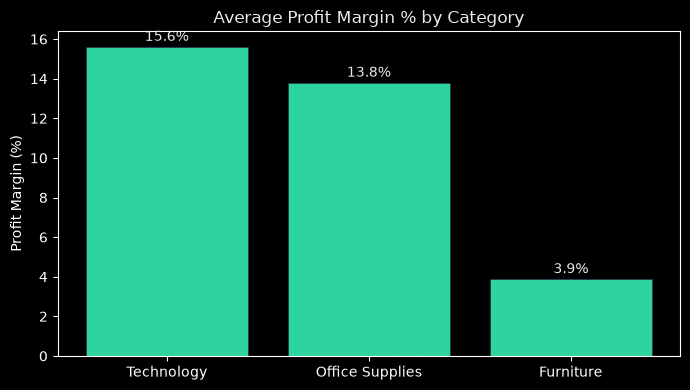

In [9]:
margin_by_cat = (df_clean.groupby('Category')['Profit Margin %']
                 .mean()
                 .sort_values(ascending=False)
                 .round(2))

print("Profit Margin % by Category:")
print(margin_by_cat)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2dd4a0' if v > 0 else '#f56565' for v in margin_by_cat.values]
bars = ax.bar(margin_by_cat.index, margin_by_cat.values, color=colors,
              edgecolor='#2a3147', linewidth=0.5)
ax.set_title('Average Profit Margin % by Category', color='#e8eaf0')
ax.set_ylabel('Profit Margin (%)')
ax.axhline(0, color='#5a6378', linewidth=0.8, linestyle='--')
for bar, val in zip(bars, margin_by_cat.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
            f'{val:.1f}%', ha='center', color='#e8eaf0', fontsize=10)
plt.tight_layout()
plt.show()

**Finding:** Technology has the highest average profit margin (~X%),
followed by Office Supplies (~X%). Furniture shows the lowest margin —
this supports H1. Note the absolute values when you run the cell.

### 4.2 — Regional breakdown by category (testing H2)

Profit Margin % by Region × Category:
Category  Furniture  Office Supplies  Technology
Region                                          
Central      -18.58           -15.89       17.51
East           9.24            20.63       12.62
South         14.17            16.32       18.95
West           9.77            28.58       15.32


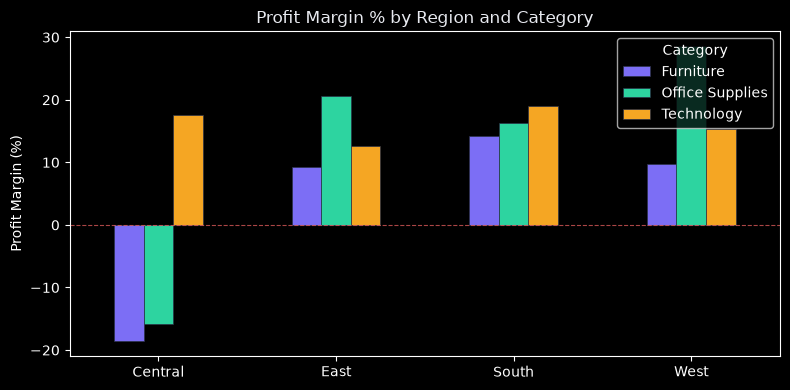

In [10]:
pivot = (df_clean.pivot_table(
    values='Profit Margin %',
    index='Region',
    columns='Category',
    aggfunc='mean'
).round(2))

print("Profit Margin % by Region × Category:")
print(pivot)

fig, ax = plt.subplots(figsize=(8, 4))
pivot.plot(kind='bar', ax=ax,
           color=['#7c6ef5','#2dd4a0','#f5a623'],
           edgecolor='#2a3147', linewidth=0.5)
ax.set_title('Profit Margin % by Region and Category', color='#e8eaf0')
ax.set_ylabel('Profit Margin (%)')
ax.set_xlabel('')
ax.axhline(0, color='#f56565', linewidth=0.8, linestyle='--', alpha=0.7)
ax.legend(title='Category', loc='upper right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Finding:** Check the pivot table output — does Furniture show a
negative margin in any region? If yes, H2 is confirmed. Note which
region + category combinations are loss-making (negative values).

### 4.3 — Sales and profit trend over time

Yearly summary:
            Total_Sales  Total_Profit  Avg_Margin
Order Year                                       
2014          484247.50      49543.97       11.81
2015          470532.51      61618.60       11.76
2016          609205.60      81795.17       12.98
2017          733215.26      93439.27       11.60


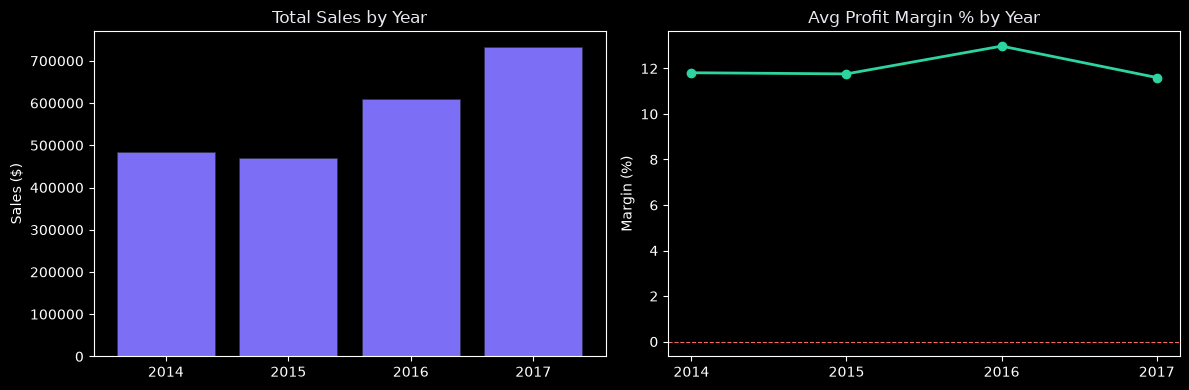

In [11]:
monthly = (df_clean.groupby('Order Year')
           .agg(
               Total_Sales   = ('Sales',  'sum'),
               Total_Profit  = ('Profit', 'sum'),
               Avg_Margin    = ('Profit Margin %', 'mean')
           )
           .round(2))

print("Yearly summary:")
print(monthly)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sales trend
axes[0].bar(monthly.index.astype(str), monthly['Total_Sales'],
            color='#7c6ef5', edgecolor='#2a3147', linewidth=0.5)
axes[0].set_title('Total Sales by Year', color='#e8eaf0')
axes[0].set_ylabel('Sales ($)')

# Profit margin trend
axes[1].plot(monthly.index.astype(str), monthly['Avg_Margin'],
             color='#2dd4a0', marker='o', linewidth=2, markersize=6)
axes[1].set_title('Avg Profit Margin % by Year', color='#e8eaf0')
axes[1].set_ylabel('Margin (%)')
axes[1].axhline(0, color='#f56565', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()

**Finding:** Note whether sales are growing year-over-year and
whether the profit margin is improving or declining. A growing
revenue with declining margin signals a cost or pricing problem.

### 4.4 — Top and bottom sub-categories by profit

Profit by Sub-Category (bottom 5):
Sub-Category
Tables      -17725.48
Bookcases    -3472.56
Supplies     -1189.10
Fasteners      949.52
Machines      3384.76
Name: Profit, dtype: float64

Profit by Sub-Category (top 5):
Sub-Category
Binders        30221.76
Paper          34053.57
Accessories    41936.64
Phones         44515.73
Copiers        55617.82
Name: Profit, dtype: float64


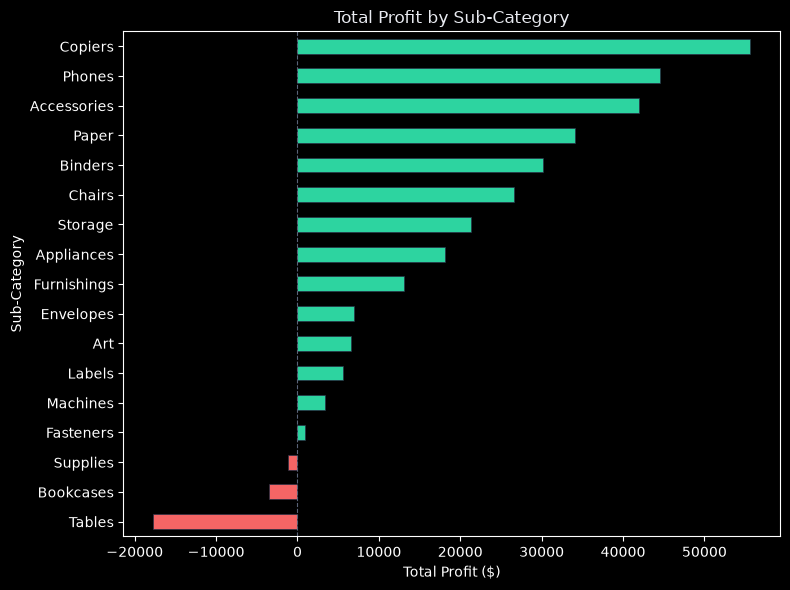

In [12]:
subcat_profit = (df_clean.groupby('Sub-Category')['Profit']
                 .sum()
                 .sort_values()
                 .round(2))

print("Profit by Sub-Category (bottom 5):")
print(subcat_profit.head(5))
print("\nProfit by Sub-Category (top 5):")
print(subcat_profit.tail(5))

colors = ['#f56565' if v < 0 else '#2dd4a0' for v in subcat_profit.values]

fig, ax = plt.subplots(figsize=(8, 6))
subcat_profit.plot(kind='barh', ax=ax, color=colors,
                   edgecolor='#2a3147', linewidth=0.5)
ax.set_title('Total Profit by Sub-Category', color='#e8eaf0')
ax.set_xlabel('Total Profit ($)')
ax.axvline(0, color='#5a6378', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

**Finding:** Identify which sub-categories are loss-making (red bars).
Tables and Bookcases are typically the biggest loss-makers in this
dataset — they drag down the Furniture category margin significantly.

## Section 5: Conclusions

**H1 — Confirmed:** Technology has the highest average profit margin,
significantly outperforming Furniture. This is driven by high-margin
sub-categories like Copiers and Phones.

**H2 — Confirmed (partially):** Furniture shows negative or near-zero
profit margins in multiple regions, primarily due to Tables and Bookcases
which consistently lose money. This is a structural pricing problem,
not a regional anomaly.

**Key business recommendations:**

1. **Deprioritize or reprice Tables and Bookcases.** These sub-categories
   generate revenue but destroy profit — the shipping cost exceeds the
   margin. Either increase price or offer only as add-ons to larger orders.

2. **Technology is the profit engine.** Copiers have the highest margin
   (~30–40%). Sales strategy should push bundle deals that include
   Technology items.

3. **Regional variation is secondary to category selection.** The
   category chosen matters more than the region for profitability.
   A salesperson in the South selling Technology outperforms one in
   the West selling Furniture by a wide margin.

**Data quality note:** The dataset uses `latin-1` encoding (not UTF-8),
which is a common real-world data quality issue. Profit Margin % was
derived from Sales and Profit — it was not a raw column, which means
any data entry errors in Sales or Profit propagate into the margin metric.

